In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import shap
import joblib

In [4]:
df = pd.read_csv("../data/raw/student-mat.csv", sep=",")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.shape

(395, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
df.info

<bound method DataFrame.info of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel fre

In [8]:
df["fail_risk"] = (df["G3"] < 10).astype(int)

df["fail_risk"].value_counts()

fail_risk
0    265
1    130
Name: count, dtype: int64

In [7]:
df.columns

Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'], dtype='object')

In [8]:
df = pd.read_csv("../data/raw/student-mat.csv", sep=";")
df.columns

Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'], dtype='object')

In [9]:
df.head()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."


In [9]:
df["fail_risk"] = (df["G3"] < 10).astype(int)
df["fail_risk"].value_counts()

fail_risk
0    265
1    130
Name: count, dtype: int64

In [11]:
df.columns

Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'], dtype='object')

In [13]:
df = pd.read_csv("../data/raw/student-mat.csv")

In [14]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [15]:
df["fail_risk"] = (df["G3"] < 10).astype(int)
df["fail_risk"].value_counts()

fail_risk
0    265
1    130
Name: count, dtype: int64

In [12]:
X = df.drop(columns=["G1", "G2", "G3", "fail_risk"])
y = df["fail_risk"]

X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,4
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,2
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,4


In [13]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(316, 30) (79, 30)
fail_risk
0    212
1    104
Name: count, dtype: int64
fail_risk
0    53
1    26
Name: count, dtype: int64


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

In [16]:
clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.759493670886076
Precision: 0.7058823529411765
Recall: 0.46153846153846156
F1 Score: 0.5581395348837209
ROC-AUC: 0.7089985486211902

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        53
           1       0.71      0.46      0.56        26

    accuracy                           0.76        79
   macro avg       0.74      0.68      0.70        79
weighted avg       0.75      0.76      0.74        79



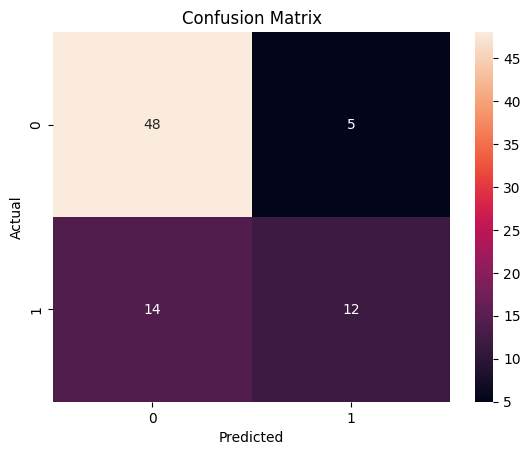

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
threshold = 0.30

y_pred_threshold = (y_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall:", recall_score(y_test, y_pred_threshold))
print("F1 Score:", f1_score(y_test, y_pred_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))

Accuracy: 0.6582278481012658
Precision: 0.48484848484848486
Recall: 0.6153846153846154
F1 Score: 0.5423728813559322
ROC-AUC: 0.7089985486211902

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73        53
           1       0.48      0.62      0.54        26

    accuracy                           0.66        79
   macro avg       0.63      0.65      0.63        79
weighted avg       0.68      0.66      0.67        79



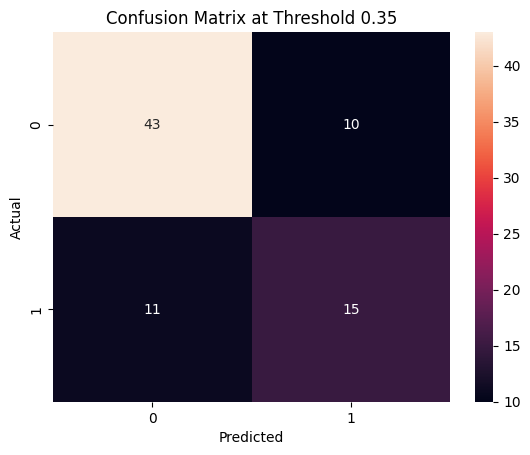

In [24]:
cm = confusion_matrix(y_test, y_pred_threshold)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix at Threshold 0.35")
plt.show()

In [20]:
FINAL_THRESHOLD = 0.30

final_y_pred = (y_proba >= FINAL_THRESHOLD).astype(int)

print("Final Threshold:", FINAL_THRESHOLD)
print("Accuracy:", accuracy_score(y_test, final_y_pred))
print("Precision:", precision_score(y_test, final_y_pred))
print("Recall:", recall_score(y_test, final_y_pred))
print("F1 Score:", f1_score(y_test, final_y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, final_y_pred))

Final Threshold: 0.3
Accuracy: 0.6582278481012658
Precision: 0.48484848484848486
Recall: 0.6153846153846154
F1 Score: 0.5423728813559322
ROC-AUC: 0.7089985486211902

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73        53
           1       0.48      0.62      0.54        26

    accuracy                           0.66        79
   macro avg       0.63      0.65      0.63        79
weighted avg       0.68      0.66      0.67        79



In [21]:
preprocessor = clf.named_steps["preprocessor"]

cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_feature_names = list(cat_feature_names) + numerical_cols

print("Total features after encoding:", len(all_feature_names))
print(all_feature_names[:20])

Total features after encoding: 56
['school_GP', 'school_MS', 'sex_F', 'sex_M', 'address_R', 'address_U', 'famsize_GT3', 'famsize_LE3', 'Pstatus_A', 'Pstatus_T', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher']


In [25]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=all_feature_names)

X_test_processed.head()

,school_GP,school_MS,sex_F,sex_M,address_R,address_U,famsize_GT3,famsize_LE3,Pstatus_A,Pstatus_T,...,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,2.0,1.0,1.0,4.0,3.0,2.0,1.0,3.0,5.0,0.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,3.0,1.0,3.0,1.0,3.0,5.0,4.0
2,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,4.0,3.0,2.0,3.0,4.0,5.0,8.0
3,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,2.0,1.0,3.0,3.0,1.0,1.0,2.0,4.0,0.0
4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,2.0,0.0,3.0,3.0,3.0,2.0,3.0,2.0,4.0


In [26]:
xgb_model = clf.named_steps["model"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_processed)

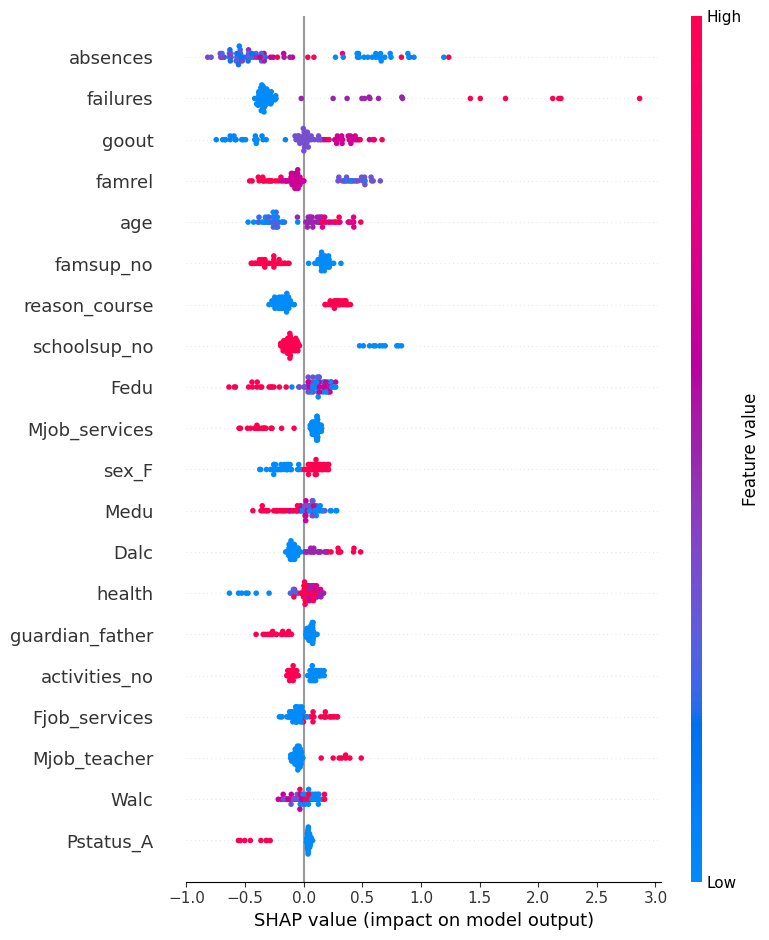

In [27]:
shap.summary_plot(shap_values, X_test_processed)

In [28]:
student_index = 0

single_student = X_test.iloc[[student_index]]
single_student_processed = X_test_processed.iloc[[student_index]]

risk_probability = clf.predict_proba(single_student)[0][1]
risk_prediction = int(risk_probability >= FINAL_THRESHOLD)

print("Risk Probability:", risk_probability)
print("Final Prediction:", "At Risk" if risk_prediction == 1 else "Not At Risk")

Risk Probability: 0.66958076
Final Prediction: At Risk


In [29]:
student_shap_values = shap_values[student_index]

reason_df = pd.DataFrame({
    "feature": X_test_processed.columns,
    "shap_value": student_shap_values,
    "feature_value": single_student_processed.iloc[0].values
})

reason_df["abs_shap"] = reason_df["shap_value"].abs()

top_reasons = reason_df.sort_values("abs_shap", ascending=False).head(10)

top_reasons

,feature,shap_value,feature_value,abs_shap
48,failures,0.842727,1.0,0.842727
51,goout,-0.667040,2.0,0.667040
55,absences,0.583924,0.0,0.583924
43,age,0.296402,19.0,0.296402
18,Fjob_services,0.267296,1.0,0.267296
45,Fedu,0.237595,1.0,0.237595
44,Medu,0.227310,1.0,0.227310
4,address_R,0.209871,1.0,0.209871
29,famsup_no,-0.208440,1.0,0.208440
50,freetime,0.162684,3.0,0.162684


In [30]:
def get_top_risk_reasons(student_index, top_n=5):
    single_student_processed = X_test_processed.iloc[[student_index]]
    student_shap_values = shap_values[student_index]

    reason_df = pd.DataFrame({
        "feature": X_test_processed.columns,
        "shap_value": student_shap_values,
        "feature_value": single_student_processed.iloc[0].values
    })

    # Positive SHAP value means pushing prediction toward failure risk
    risk_reasons = reason_df[reason_df["shap_value"] > 0].copy()
    risk_reasons["abs_shap"] = risk_reasons["shap_value"].abs()

    return risk_reasons.sort_values("abs_shap", ascending=False).head(top_n)

In [33]:
get_top_risk_reasons(0)

,feature,shap_value,feature_value,abs_shap
48,failures,0.842727,1.0,0.842727
55,absences,0.583924,0.0,0.583924
43,age,0.296402,19.0,0.296402
18,Fjob_services,0.267296,1.0,0.267296
45,Fedu,0.237595,1.0,0.237595


In [34]:
def generate_intervention_plan(student_row, top_reason_features):
    interventions = []

    if "absences" in top_reason_features or student_row["absences"] > 10:
        interventions.append("Monitor attendance and contact the student if absences continue.")

    if "studytime" in top_reason_features or student_row["studytime"] <= 2:
        interventions.append("Create a weekly study schedule and recommend extra study sessions.")

    if "failures" in top_reason_features or student_row["failures"] > 0:
        interventions.append("Assign academic mentoring because the student has past failures.")

    if "goout" in top_reason_features or student_row["goout"] >= 4:
        interventions.append("Discuss time management and reduce non-academic distractions.")

    if "health" in top_reason_features and student_row["health"] <= 2:
        interventions.append("Recommend counselling or health support if needed.")

    if "schoolsup_yes" in top_reason_features:
        interventions.append("Continue school support and review whether current support is effective.")

    if len(interventions) == 0:
        interventions.append("Schedule a faculty check-in and monitor performance in the next assessment.")

    return interventions

In [35]:
def predict_student_risk(student_index):
    student = X_test.iloc[[student_index]]
    student_original = X_test.iloc[student_index]

    probability = clf.predict_proba(student)[0][1]
    prediction = int(probability >= FINAL_THRESHOLD)

    top_reasons_df = get_top_risk_reasons(student_index, top_n=5)
    top_reason_features = top_reasons_df["feature"].tolist()

    interventions = generate_intervention_plan(student_original, top_reason_features)

    result = {
        "student_index": student_index,
        "risk_probability": round(probability, 3),
        "prediction": "At Risk" if prediction == 1 else "Not At Risk",
        "top_reasons": top_reason_features,
        "intervention_plan": interventions
    }

    return result

In [36]:
predict_student_risk(0)

{'student_index': 0,
 'risk_probability': np.float32(0.67),
 'prediction': 'At Risk',
 'top_reasons': ['failures', 'absences', 'age', 'Fjob_services', 'Fedu'],
 'intervention_plan': ['Monitor attendance and contact the student if absences continue.',
  'Create a weekly study schedule and recommend extra study sessions.',
  'Assign academic mentoring because the student has past failures.']}

In [37]:
predict_student_risk(5)

{'student_index': 5,
 'risk_probability': np.float32(0.808),
 'prediction': 'At Risk',
 'top_reasons': ['absences', 'famrel', 'Dalc', 'age', 'famsup_no'],
 'intervention_plan': ['Monitor attendance and contact the student if absences continue.',
  'Create a weekly study schedule and recommend extra study sessions.']}

In [38]:
results = X_test.copy()

results["actual_fail_risk"] = y_test.values
results["risk_probability"] = y_proba
results["predicted_fail_risk"] = final_y_pred

results["risk_label"] = results["predicted_fail_risk"].map({
    0: "Not At Risk",
    1: "At Risk"
})

results.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,actual_fail_risk,risk_probability,predicted_fail_risk,risk_label
383,MS,M,19,R,GT3,T,1,1,other,services,...,3,2,1,3,5,0,1,0.669581,1,At Risk
19,GP,M,16,U,LE3,T,4,3,health,other,...,1,3,1,3,5,4,0,0.129497,0,Not At Risk
193,GP,M,16,R,GT3,T,3,3,services,services,...,3,2,3,4,5,8,0,0.126562,0,Not At Risk
343,GP,F,17,U,GT3,A,2,2,at_home,at_home,...,3,1,1,2,4,0,1,0.479873,1,At Risk
92,GP,F,16,U,LE3,T,3,1,other,other,...,3,3,2,3,2,4,1,0.529538,1,At Risk


In [40]:
all_interventions = []
all_top_reasons = []

for i in range(len(X_test)):
    result = predict_student_risk(i)
    all_top_reasons.append(", ".join(result["top_reasons"]))
    all_interventions.append(" | ".join(result["intervention_plan"]))

results["top_risk_reasons"] = all_top_reasons
results["intervention_plan"] = all_interventions

results.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,actual_fail_risk,risk_probability,predicted_fail_risk,risk_label,top_risk_reasons,intervention_plan
383,MS,M,19,R,GT3,T,1,1,other,services,...,1,3,5,0,1,0.669581,1,At Risk,"failures, absences, age, Fjob_services, Fedu",Monitor attendance and contact the student if ...
19,GP,M,16,U,LE3,T,4,3,health,other,...,1,3,5,4,0,0.129497,0,Not At Risk,"famrel, Fedu, freetime, Mjob_services, activit...",Create a weekly study schedule and recommend e...
193,GP,M,16,R,GT3,T,3,3,services,services,...,3,4,5,8,0,0.126562,0,Not At Risk,"Dalc, address_R, famsup_no, Fedu, freetime",Create a weekly study schedule and recommend e...
343,GP,F,17,U,GT3,A,2,2,at_home,at_home,...,1,2,4,0,1,0.479873,1,At Risk,"absences, failures, famrel, famsup_no, age",Monitor attendance and contact the student if ...
92,GP,F,16,U,LE3,T,3,1,other,other,...,2,3,2,4,1,0.529538,1,At Risk,"famrel, schoolsup_no, famsup_no, schoolsup_yes...",Create a weekly study schedule and recommend e...


In [41]:
results.to_csv("../data/processed/failsafe_predictions.csv", index=False)

print("Saved predictions to ../data/processed/failsafe_predictions.csv")

Saved predictions to ../data/processed/failsafe_predictions.csv


In [42]:
joblib.dump(clf, "../models/failsafe_model.pkl")
joblib.dump(FINAL_THRESHOLD, "../models/failsafe_threshold.pkl")
joblib.dump(all_feature_names, "../models/failsafe_feature_names.pkl")

print("Model, threshold, and feature names saved successfully.")

Model, threshold, and feature names saved successfully.
